In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import os
os.getcwd()

'C:\\ML\\insurance-fraud-detection-ml-main\\Epic_5'

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'employee_data.csv',
 'epic5_model.pkl',
 'epic5_temp.ipynb',
 'fraud_detection_model.pkl',
 'insurance_cleaned.csv',
 'insurance_data.csv',
 'vendor_data.csv',
 'X_test.pkl',
 'y_test.pkl']

In [4]:
employee = pd.read_csv("employee_data.csv")
vendor = pd.read_csv("vendor_data.csv")
insurance = pd.read_csv("insurance_data.csv")
claim = pd.read_csv("insurance_cleaned.csv")

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load data
data = pd.read_csv("insurance_cleaned.csv")

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

# Target and features
y = data["CLAIM_STATUS"]
X = data.drop("CLAIM_STATUS", axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier()

grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


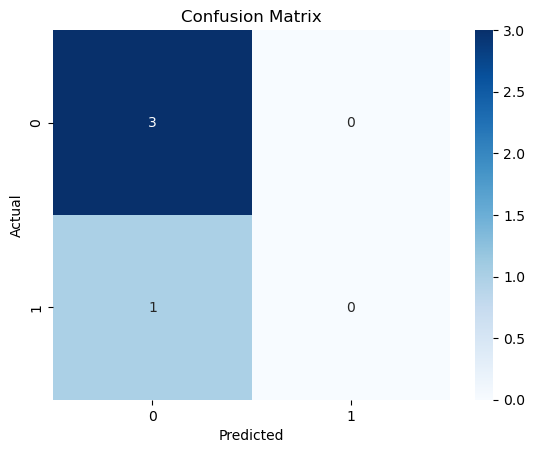

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:
print(best_model.feature_importances_)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [8]:
import pandas as pd

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

print(feature_importance.head(10))

                     Feature  Importance
0              POLICY_EFF_DT         0.0
1                    LOSS_DT         0.0
26                 VENDOR_ID         0.0
25                  AGENT_ID         0.0
24  INCIDENT_HOUR_OF_THE_DAY         0.0
23             INCIDENT_CITY         0.0
22            INCIDENT_STATE         0.0
21   POLICE_REPORT_AVAILABLE         0.0
20                ANY_INJURY         0.0
19       AUTHORITY_CONTACTED         0.0


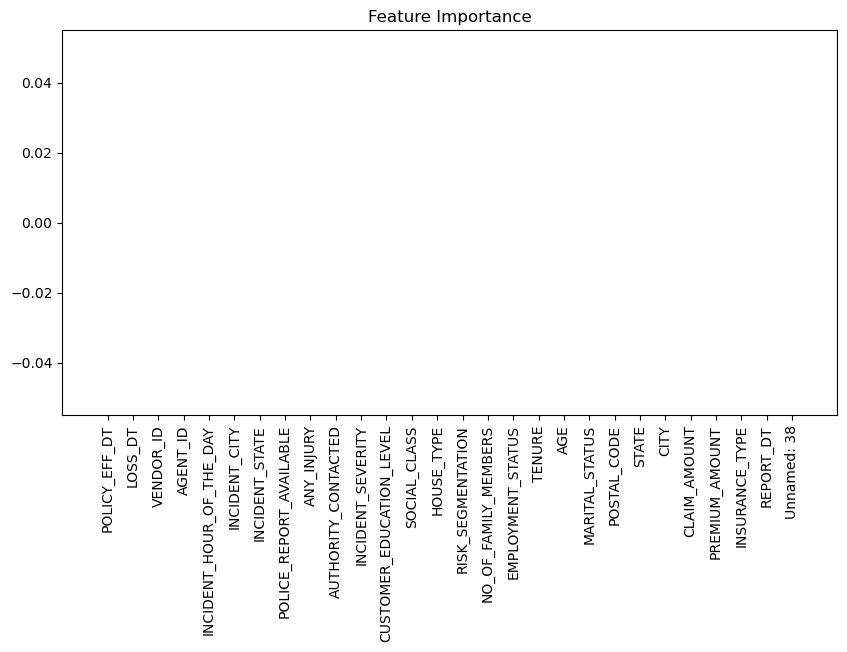

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [10]:
import joblib
joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [11]:
import joblib

base_model = joblib.load("../Epic_4/epic4_final_model.pkl")

In [12]:
import pandas as pd

df = pd.read_csv("../Epic_4/insurance_model_ready.csv")

In [13]:
df["is_fraud"] = df["CLAIM_STATUS"].map({"D": 1, "A": 0})

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(["CLAIM_STATUS", "is_fraud"], axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
y_pred_epic4 = base_model.predict(X_test)

In [16]:
import pandas as pd

y_pred_epic4 = pd.Series(y_pred_epic4).map({"D": 1, "A": 0}).values

In [17]:
y_test = y_test.astype(int)

In [18]:
from sklearn.metrics import classification_report

print("===== Epic 4 Model Performance on Epic 5 Data =====")
print(classification_report(y_test, y_pred_epic4))

===== Epic 4 Model Performance on Epic 5 Data =====
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
y_pred_epic4 = base_model.predict(X_test)

import pandas as pd
y_pred_epic4 = pd.Series(y_pred_epic4).map({"D": 1, "A": 0}).values

y_test = y_test.astype(int)

from sklearn.metrics import classification_report
print("===== Epic 4 Model Performance on Epic 5 Data =====")
print(classification_report(y_test, y_pred_epic4))

===== Epic 4 Model Performance on Epic 5 Data =====
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [20]:
df = pd.read_csv("../Epic_2/insurance_cleaned.csv")  # adjust path if needed
df.head()


,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CITY,STATE,POSTAL_CODE,MARITAL_STATUS,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,318,19,22,0,157.13,9000,39,3,85308,1,...,0,0,2,0,1,9,100,4,143,208
1,296,13,18,4,141.71,26000,6,5,80005,0,...,0,2,0,1,0,1,61,0,270,222
2,30,27,27,4,157.24,13000,104,4,94591,0,...,0,2,2,0,1,5,35,19,307,8
3,422,15,20,0,172.87,16000,102,9,31404,1,...,0,1,0,0,0,9,100,12,93,21
4,376,21,23,5,88.53,3000,51,4,94550,1,...,0,0,2,0,1,14,65,18,222,170


In [21]:
df["CLAIM_STATUS"].value_counts()

CLAIM_STATUS
0    470
1     30
Name: count, dtype: int64

In [22]:
# Create binary target: 1 = Fraud (Denied), 0 = Not Fraud (Approved)
df["is_fraud"] = df["CLAIM_STATUS"].map({"D": 1, "A": 0})

In [23]:
X = df.drop(["CLAIM_STATUS", "is_fraud"], axis=1)
y = df["is_fraud"]

In [24]:
drop_cols = [
    "TRANSACTION_ID", "CUSTOMER_ID", "POLICY_NUMBER",
    "SSN", "ROUTING_NUMBER", "ACCT_NUMBER",
    "CUSTOMER_NAME", "ADDRESS_LINE1", "ADDRESS_LINE2"
]

X = X.drop(columns=drop_cols, errors="ignore")

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
import pandas as pd

# Load datasets
employee = pd.read_csv("employee_data.csv")
vendor = pd.read_csv("vendor_data.csv")
insurance = pd.read_csv("insurance_data.csv")

# Merge Employee + Insurance
emp_ins = pd.merge(employee, insurance, on="AGENT_ID", how="inner")

# Merge with Vendor
final_df = pd.merge(emp_ins, vendor, on="VENDOR_ID", how="inner")

print("Merged dataset shape:", final_df.shape)
print(final_df.columns)

Merged dataset shape: (71, 53)
Index(['AGENT_ID', 'AGENT_NAME', 'DATE_OF_JOINING', 'ADDRESS_LINE1_x',
       'ADDRESS_LINE2_x', 'CITY_x', 'STATE_x', 'POSTAL_CODE_x',
       'EMP_ROUTING_NUMBER', 'EMP_ACCT_NUMBER', 'TXN_DATE_TIME',
       'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER', 'POLICY_EFF_DT',
       'LOSS_DT', 'REPORT_DT', 'INSURANCE_TYPE', 'PREMIUM_AMOUNT',
       'CLAIM_AMOUNT', 'CUSTOMER_NAME', 'ADDRESS_LINE1_y', 'ADDRESS_LINE2_y',
       'CITY_y', 'STATE_y', 'POSTAL_CODE_y', 'SSN', 'MARITAL_STATUS', 'AGE',
       'TENURE', 'EMPLOYMENT_STATUS', 'NO_OF_FAMILY_MEMBERS',
       'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS', 'ROUTING_NUMBER',
       'ACCT_NUMBER', 'CUSTOMER_EDUCATION_LEVEL', 'CLAIM_STATUS',
       'INCIDENT_SEVERITY', 'AUTHORITY_CONTACTED', 'ANY_INJURY',
       'POLICE_REPORT_AVAILABLE', 'INCIDENT_STATE', 'INCIDENT_CITY',
       'INCIDENT_HOUR_OF_THE_DAY', 'VENDOR_ID', 'VENDOR_NAME', 'ADDRESS_LINE1',
       'ADDRESS_LINE2', 'CITY', 'STATE', 'POSTAL_CODE']

In [27]:
import pandas as pd

# Suppose final_df is your merged dataset
final_df_encoded = pd.get_dummies(final_df, drop_first=True)

print("Encoding done. Columns now:", final_df_encoded.columns)

Encoding done. Columns now: Index(['POSTAL_CODE_x', 'EMP_ROUTING_NUMBER', 'PREMIUM_AMOUNT', 'CLAIM_AMOUNT',
       'POSTAL_CODE_y', 'AGE', 'TENURE', 'NO_OF_FAMILY_MEMBERS',
       'ROUTING_NUMBER', 'ANY_INJURY',
       ...
       'STATE_AZ', 'STATE_CA', 'STATE_CO', 'STATE_CT', 'STATE_DC', 'STATE_GA',
       'STATE_KY', 'STATE_MA', 'STATE_MD', 'STATE_TN'],
      dtype='object', length=1369)


In [28]:
print(final_df.columns)

Index(['AGENT_ID', 'AGENT_NAME', 'DATE_OF_JOINING', 'ADDRESS_LINE1_x',
       'ADDRESS_LINE2_x', 'CITY_x', 'STATE_x', 'POSTAL_CODE_x',
       'EMP_ROUTING_NUMBER', 'EMP_ACCT_NUMBER', 'TXN_DATE_TIME',
       'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER', 'POLICY_EFF_DT',
       'LOSS_DT', 'REPORT_DT', 'INSURANCE_TYPE', 'PREMIUM_AMOUNT',
       'CLAIM_AMOUNT', 'CUSTOMER_NAME', 'ADDRESS_LINE1_y', 'ADDRESS_LINE2_y',
       'CITY_y', 'STATE_y', 'POSTAL_CODE_y', 'SSN', 'MARITAL_STATUS', 'AGE',
       'TENURE', 'EMPLOYMENT_STATUS', 'NO_OF_FAMILY_MEMBERS',
       'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS', 'ROUTING_NUMBER',
       'ACCT_NUMBER', 'CUSTOMER_EDUCATION_LEVEL', 'CLAIM_STATUS',
       'INCIDENT_SEVERITY', 'AUTHORITY_CONTACTED', 'ANY_INJURY',
       'POLICE_REPORT_AVAILABLE', 'INCIDENT_STATE', 'INCIDENT_CITY',
       'INCIDENT_HOUR_OF_THE_DAY', 'VENDOR_ID', 'VENDOR_NAME', 'ADDRESS_LINE1',
       'ADDRESS_LINE2', 'CITY', 'STATE', 'POSTAL_CODE'],
      dtype='object')


In [29]:
print(final_df_encoded.columns.tolist())

['POSTAL_CODE_x', 'EMP_ROUTING_NUMBER', 'PREMIUM_AMOUNT', 'CLAIM_AMOUNT', 'POSTAL_CODE_y', 'AGE', 'TENURE', 'NO_OF_FAMILY_MEMBERS', 'ROUTING_NUMBER', 'ANY_INJURY', 'POLICE_REPORT_AVAILABLE', 'INCIDENT_HOUR_OF_THE_DAY', 'POSTAL_CODE', 'AGENT_ID_AGENT00015', 'AGENT_ID_AGENT00024', 'AGENT_ID_AGENT00027', 'AGENT_ID_AGENT00030', 'AGENT_ID_AGENT00048', 'AGENT_ID_AGENT00050', 'AGENT_ID_AGENT00063', 'AGENT_ID_AGENT00064', 'AGENT_ID_AGENT00066', 'AGENT_ID_AGENT00068', 'AGENT_ID_AGENT00070', 'AGENT_ID_AGENT00077', 'AGENT_ID_AGENT00094', 'AGENT_ID_AGENT00099', 'AGENT_ID_AGENT00107', 'AGENT_ID_AGENT00111', 'AGENT_ID_AGENT00116', 'AGENT_ID_AGENT00123', 'AGENT_ID_AGENT00129', 'AGENT_ID_AGENT00137', 'AGENT_ID_AGENT00140', 'AGENT_ID_AGENT00148', 'AGENT_ID_AGENT00161', 'AGENT_ID_AGENT00170', 'AGENT_ID_AGENT00173', 'AGENT_ID_AGENT00176', 'AGENT_ID_AGENT00196', 'AGENT_ID_AGENT00205', 'AGENT_ID_AGENT00207', 'AGENT_ID_AGENT00214', 'AGENT_ID_AGENT00242', 'AGENT_ID_AGENT00266', 'AGENT_ID_AGENT00278', 'AGENT_

In [30]:
# Replace 'CLAIM_STATUS' with the exact name from your dataframe
X = final_df_encoded.drop("CLAIM_AMOUNT", axis=1)
y = final_df_encoded["CLAIM_AMOUNT"]

In [31]:
print(final_df_encoded["CLAIM_AMOUNT"].isna().sum())

0


In [32]:
from sklearn.ensemble import RandomForestRegressor

X = final_df_encoded.drop("CLAIM_AMOUNT", axis=1)
y = final_df_encoded["CLAIM_AMOUNT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# Drop rows with very rare class
counts = final_df["CLAIM_STATUS"].value_counts()
rare_classes = counts[counts < 2].index
final_df = final_df[~final_df["CLAIM_STATUS"].isin(rare_classes)]

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of sa

Baseline Accuracy: 0.13333333333333333
              precision    recall  f1-score   support

         100       0.00      0.00      0.00         2
         300       0.00      0.00      0.00         0
         700       0.00      0.00      0.00         1
        2000       0.00      0.00      0.00         2
        3000       0.00      0.00      0.00         0
        4000       0.00      0.00      0.00         0
        5000       1.00      1.00      1.00         1
        6000       1.00      1.00      1.00         1
        7000       0.00      0.00      0.00         0
       15000       0.00      0.00      0.00         0
       16000       0.00      0.00      0.00         1
       17000       0.00      0.00      0.00         1
       25000       0.00      0.00      0.00         2
       31000       0.00      0.00      0.00         1
       49000       0.00      0.00      0.00         1
       70000       0.00      0.00      0.00         1
       86000       0.00      0.00      0.0

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of sa

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:2734: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  and (type_of_target(y, input_name="y") in ("binary", "multiclass"))
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:784: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_of_target_y = type_of_target(y)
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Accuracy: 0.13333333333333333
              precision    recall  f1-score   support

         100       0.00      0.00      0.00         2
         300       0.00      0.00      0.00         0
         700       0.00      0.00      0.00         1
        2000       0.00      0.00      0.00         2
        3000       0.00      0.00      0.00         0
        4000       0.00      0.00      0.00         0
        5000       1.00      1.00      1.00         1
        6000       1.00      1.00      1.00         1
        7000       0.00      0.00      0.00         0
       15000       0.00      0.00      0.00         0
       16000       0.00      0.00      0.00         1
       17000       0.00      0.00      0.00         1
       25000       0.00      0.00      0.00         2
       31000       0.00      0.00      0.00         1
       49000       0.00      0.00      0.00         1
       70000     

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of sa

In [36]:
print("=== Before Tuning ===")
print(classification_report(y_test, y_pred_base))

print("\n=== After Tuning ===")
print(classification_report(y_test, y_pred_tuned))

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-pa

=== Before Tuning ===
              precision    recall  f1-score   support

         100       0.00      0.00      0.00         2
         300       0.00      0.00      0.00         0
         700       0.00      0.00      0.00         1
        2000       0.00      0.00      0.00         2
        3000       0.00      0.00      0.00         0
        4000       0.00      0.00      0.00         0
        5000       1.00      1.00      1.00         1
        6000       1.00      1.00      1.00         1
        7000       0.00      0.00      0.00         0
       15000       0.00      0.00      0.00         0
       16000       0.00      0.00      0.00         1
       17000       0.00      0.00      0.00         1
       25000       0.00      0.00      0.00         2
       31000       0.00      0.00      0.00         1
       49000       0.00      0.00      0.00         1
       70000       0.00      0.00      0.00         1
       86000       0.00      0.00      0.00         1

    

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tanvi\anaconda3\Lib\site-pa

In [37]:
import joblib

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

In [38]:
print(X_test)

    POSTAL_CODE_x  EMP_ROUTING_NUMBER  PREMIUM_AMOUNT  POSTAL_CODE_y  AGE  \
22          40245            52933002           95.12          21122   62   
0           85302            53819552           89.76          31401   37   
49          85306            41034129           56.26          73013   61   
4           94587            82810894          134.71          31405   45   
55          31406            16642203           10.66          40204   55   
18          80002           123653318           75.68          40203   56   
10           6040            49124264          124.60          36105   28   
33          73071            87652976          172.87          31404   36   
46          32405            80018643            6.76          72101   55   
12          73071           115478394          103.98          31419   44   
31          36104            53225654           98.28          20011   62   
9            1607           101490043          151.18           5761   38   

In [39]:
import joblib
joblib.dump(X_test, "X_test.pkl")

['X_test.pkl']

In [40]:
import joblib

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib

# Define hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Base model
rfc = RandomForestClassifier(random_state=42)

# Grid Search
grid = GridSearchCV(rfc, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best hyperparameters:", grid.best_params_)

# Save model and test data
joblib.dump(best_model, "epic5_model.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:2734: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  and (type_of_target(y, input_name="y") in ("binary", "multiclass"))
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:784: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_of_target_y = type_of_target(y)
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\tanvi\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a 

Best hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


['y_test.pkl']